# Exploratory Data Analysis

This notebook explores the cleaned BoardGameGeek dataset to better understand the available information before building a machine-learning model.

The analysis will examine:

- the claened dataset structure;
- remaining missing values;
- the distribution of `Rating Average`;
- numerical feature distributions;
- relationships between numerical features and the prdiction target;
- the `Mechanics` and `Domains` columns;
- important findings that may affect feature engineering and modling

## Load and Verify the Cleaned Dataset

The cleaned BoardGameGeek dataset is loaded from the `data/processed` folder.

Before beggining the exploratory analysis, the file path, dataset dimensions, column names, 
duplicate records, and prediction target is checked to confirm that the correct dataset has been loaded.


In [1]:
# Import Pandas for working with tabular data
import pandas as pd

import matplotlib.pyplot as plt

# Import Path for creating file paths that work
# reliably across different OS-s
from pathlib import Path


# Find the folder from were notebook is running
current_folder = Path.cwd()

# Notebook is inside the "notebooks" folder,
# so its parent folder is the main project folder
project_root = current_folder.parent

# Create the complete path to the cleaned dataset
cleaned_data_path = (
    project_root
    / "data"
    / "processed"
    / "bgg_cleaned.csv"
)

print("Current folder:", current_folder)
print("Project root:", project_root)
print("Cleaned dataset path:", cleaned_data_path)
print("File exists:", cleaned_data_path.exists())

Current folder: c:\Users\Zombie\Desktop\vscode-projects\board-game-rating-predictor\notebooks
Project root: c:\Users\Zombie\Desktop\vscode-projects\board-game-rating-predictor
Cleaned dataset path: c:\Users\Zombie\Desktop\vscode-projects\board-game-rating-predictor\data\processed\bgg_cleaned.csv
File exists: True


In [2]:
# Load the cleaned CSV file into a Pandas DataFrame
df_eda = pd.read_csv(cleaned_data_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df_eda.shape)

Dataset loaded successfully.
Dataset shape: (20342, 14)


In [3]:
# Display the first five rows of the cleaned dataset
df_eda.head()

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1.0,4.0,120.0,14.0,42055,8.79,1,3.86,68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,161936.0,Pandemic Legacy: Season 1,2015.0,2.0,4.0,60.0,13.0,41643,8.61,2,2.84,65294.0,"Action Points, Cooperative Game, Hand Manageme...","Strategy Games, Thematic Games"
2,224517.0,Brass: Birmingham,2018.0,2.0,4.0,120.0,14.0,19217,8.66,3,3.91,28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
3,167791.0,Terraforming Mars,2016.0,1.0,5.0,120.0,12.0,64864,8.43,4,3.24,87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
4,233078.0,Twilight Imperium: Fourth Edition,2017.0,3.0,6.0,480.0,14.0,13468,8.70,5,4.22,16831.0,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"


In [4]:
# Define the column names that I expect the cleaned dataset contains
expected_columns = [
    "ID",
    "Name", 
    "Year Published",
    "Min Players",
    "Max Players",
    "Play Time",
    "Min Age",
    "Users Rated",
    "Rating Average",
    "BGG Rank",
    "Complexity Average",
    "Owned Users",
    "Mechanics",
    "Domains"
]


# Check that if loaded dataset is matchng the expected cleaned dataset
print("Correct number of rows:", df_eda.shape[0] == 20342)
print("Correct number of columns:", df_eda.shape[1] == 14)

print(
    "Column names match:",
    df_eda.columns.tolist() == expected_columns
)

print(
    "Fully duplicated rows:",
    df_eda.duplicated().sum()
)

print(
    "Missing Rating Average values:",
    df_eda["Rating Average"].isnull().sum()
)

Correct number of rows: True
Correct number of columns: True
Column names match: True
Fully duplicated rows: 0
Missing Rating Average values: 0


## Review Remaining Missing Valeus

Some missing values remain in the cleaned dataset intentionally.

These values include information that was already absent in the original dataset and zero placeholders that were converted to proper missing values during data cleaning.

The number and percenage of missing values are reviewed before deciding how they should be handled during feature engineering and model preparation.


In [5]:
# Count missing values is every column
missing_summary = df_eda.isnull().sum().to_frame(
    name="Missing Values"
)

# Calculate the percentage of the dataset
# that is missing in every column
# then divide each count by len(df_eda)
# then multiply by 100 - to changes to percentage
missing_summary["Missing Percentage"] = (
    missing_summary["Missing Values"]
    / len(df_eda)
    * 100 
).round(2)

# Keep only columns that contain mimimum one missing value
missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
]

# Sort missing percentage from largest > smallest
missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

,Missing Values,Missing Percentage
Min Age,1250,6.14
Play Time,556,2.73
Complexity Average,426,2.09
Year Published,185,0.91
Max Players,161,0.79
Min Players,46,0.23
Owned Users,22,0.11
ID,15,0.07


### Remaining Missing Values Result

The cleaned dataset contains remaining missing values in eight columns.

`Min Age` has the largest amunt of missing information, with 1,250 missing values, representing 6.14% of the dataset. The remaining columns each have less than 3% missing data.

Most of these missing values were intentionslly retained or created during data cleaning when invalid zero placeholders were converted to proper missing values.

The prediction target, `Rating Average`, contains no missing values.

No additional values will be filled or removed druing exploratory data analysis. The missing feature values will be handled later during feature engineering and model preprocessing to avoid making modelling decisions too erly.


## Explore the Rating Average Target Distribution

`Rating Average` is the prediction target for this project.

Before buildin a machine-learning model, the target column is examined to understand its typical values, spread, minimum and maximum ratings, and overall distribution.

This helps identify weather the ratings are balanced, skewed, or concentrated around particular range.


In [6]:
# Display summary statictics for the prediction target
df_eda["Rating Average"].describe()

count    20342.000000
mean         6.403233
std          0.935933
min          1.050000
25%          5.820000
50%          6.430000
75%          7.030000
max          9.580000
Name: Rating Average, dtype: float64

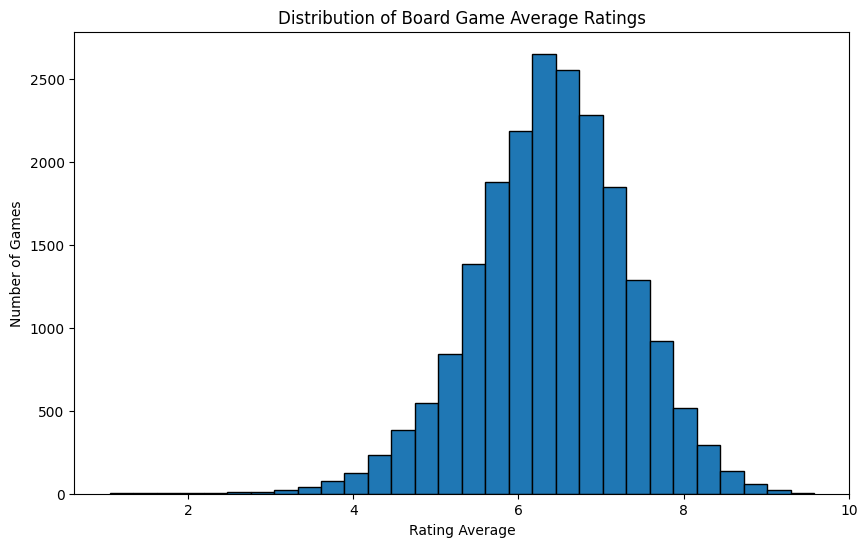

In [7]:
# Import Matplotlib for creating charts
# need to move this to top to avoid error
# import matplotlib.pyplot as plt


# Create histogram to show how Rating Average value is distrubuted
plt.figure(figsize=(10, 6))
# need to drop this to avoid error
# import pandas as pd
# from pathlib import Path
plt.hist(
    df_eda["Rating Average"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Board Game Average Ratings")
plt.xlabel("Rating Average")
plt.ylabel("Number of Games")

plt.show()

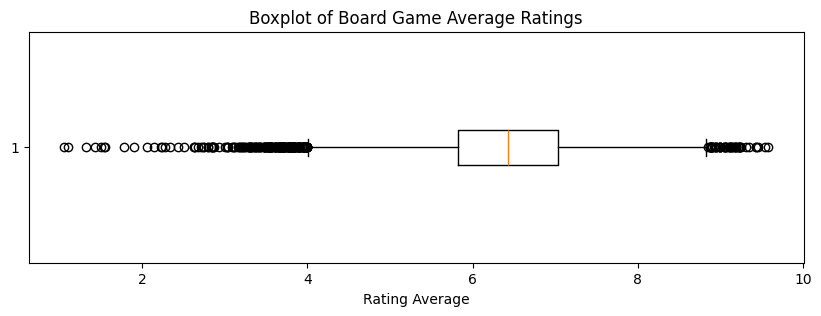

In [8]:
# Create a boxplot to show the sperad of Rating Average values
# midle range, nmedian rating, if any unusually low or high rating
plt.figure(figsize=(10, 3))

plt.boxplot(
    df_eda["Rating Average"],
    vert=False
)

plt.title("Boxplot of Board Game Average Ratings")
plt.xlabel("Rating Average")

plt.show()

In [9]:
# Group ratings into simple rating bands
rating_bins = pd.cut(
    df_eda["Rating Average"],
    bins=[0, 4, 5, 6, 7, 8, 9, 10],
    labels=[
        "0-4",
        "4-5",
        "5-6",
        "6-7",
        "7-8",
        "8-9",
        "9-10"
    ]
)

# Count how many games fall into each rating band
rating_band_counts = rating_bins.value_counts().sort_index()

rating_band_counts

Rating Average
0-4      210
4-5     1188
5-6     5102
6-7     8604
7-8     4460
8-9      746
9-10      32
Name: count, dtype: int64

In [10]:
# Convert rating-band counts into percentages
rating_band_percentages = (
    rating_band_counts
    / len(df_eda)
    * 100
).round(2)

rating_band_percentages

Rating Average
0-4      1.03
4-5      5.84
5-6     25.08
6-7     42.30
7-8     21.93
8-9      3.67
9-10     0.16
Name: count, dtype: float64

### Rating Average Distribution Result

The `Rating Average` target contains 20,342 valid values and not missing data.

The average rating is approximetely 6.40, while the median rating is approximetely 6.43. These values are very close, suggesting that the target distribution is reasonably centred around the middle rating range.

Most board games are rated between 5 and 8. The bigest band is 6-7, which contains 8,604 games, representing 42.30% of the dataset.

Approximately 89% of games fall between ratings 5 and 8. Very low ratings below 4 and very high ratings above 9 are rare.

The histogram shows that ratings are concentrated around the 6-7 range, while the bloxplot shows some low and high outliers. These outliers appear reasonlable for board game ratings and will be kept during exploratory analysis.


## Explore Numerical Feature Distributions

The numberical candidate features are explored to understood their typical values, spread, missing values, and possible outliers.

This step focuses on features that may be useful for predicting `Rating Average`:

* `Year Published`
* `Min Players`
* `Max Players`
* `Play Time`
* `Min Age`
* `Complexity Average`

Popularity-related columns such as `Users Rated`, `Owned Users`, and `BGG Rank` are not threated as initial model features because they may contain post-release popularity or ranking infromation.


In [11]:
# Defines numerical candidate features for EDA
numeric_features = [
    "Year Published",
    "Min Players",
    "Max Players",
    "Play Time",
    "Min Age",
    "Complexity Average"
]

numeric_features

['Year Published',
 'Min Players',
 'Max Players',
 'Play Time',
 'Min Age',
 'Complexity Average']

In [12]:
# Display the summary statistics for thr numerical candidate features
# The .T turns the table sideways to easier read
df_eda[numeric_features].describe().T



,count,mean,std,min,25%,50%,75%,max
Year Published,20157.0,2002.461229,98.733846,-3500.0,2001.00,2011.0,2016.00,2022.0
Min Players,20296.0,2.024291,0.684428,1.0,2.00,2.0,2.00,10.0
Max Players,20181.0,5.717655,15.283906,1.0,4.00,4.0,6.00,999.0
Play Time,19786.0,93.862580,552.853929,1.0,30.00,45.0,90.00,60000.0
Min Age,19092.0,10.230620,2.779102,1.0,8.00,10.0,12.00,25.0
Complexity Average,19916.0,2.033778,0.805892,1.0,1.33,2.0,2.57,5.0


In [13]:
# Review missing values only for selected numerical candidate fetures
numeric_missing_summary = df_eda[numeric_features].isnull().sum().to_frame(
    name="Missing Values"
)

numeric_missing_summary["Missing Percentage"] = (
    numeric_missing_summary["Missing Values"]
    / len(df_eda)
    * 100
).round(2)

numeric_missing_summary

,Missing Values,Missing Percentage
Year Published,185,0.91
Min Players,46,0.23
Max Players,161,0.79
Play Time,556,2.73
Min Age,1250,6.14
Complexity Average,426,2.09


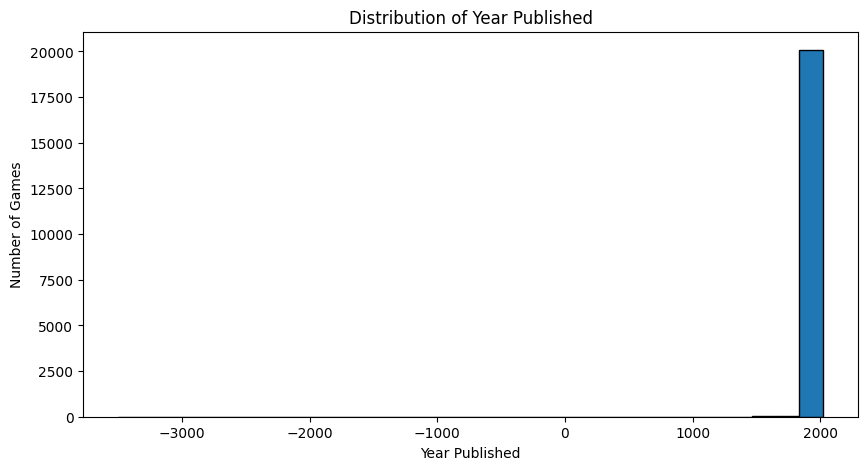

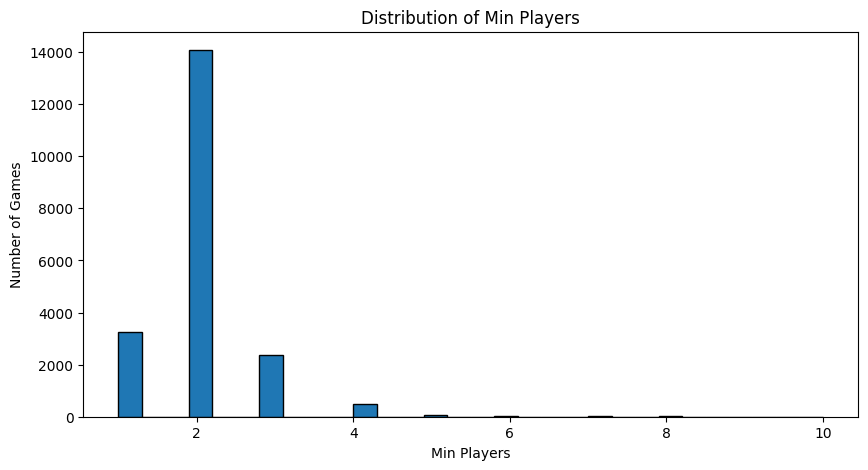

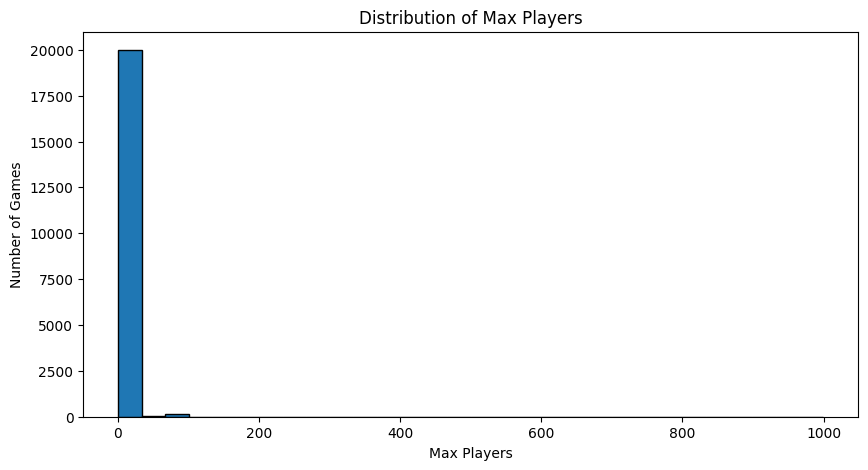

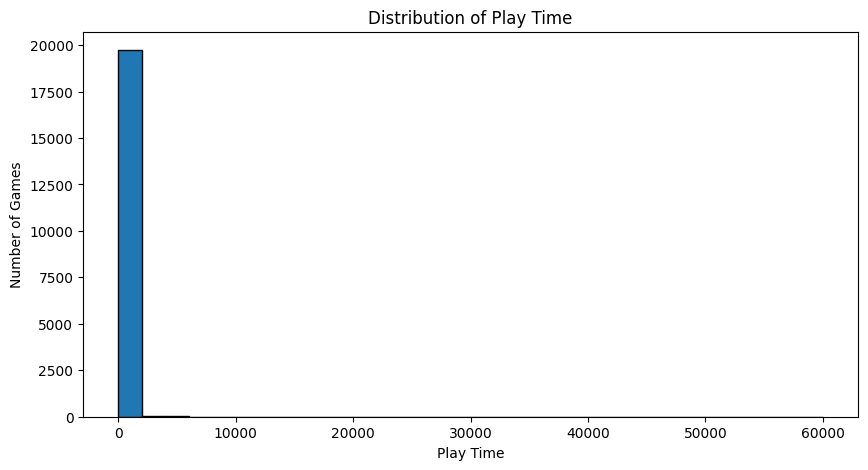

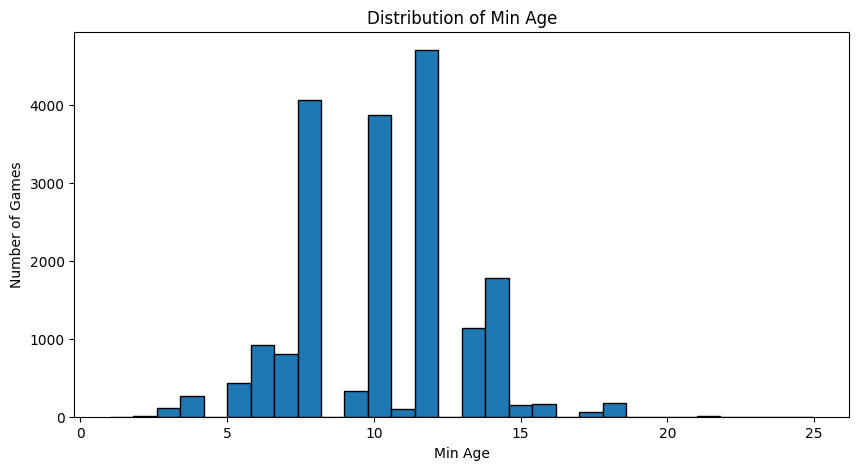

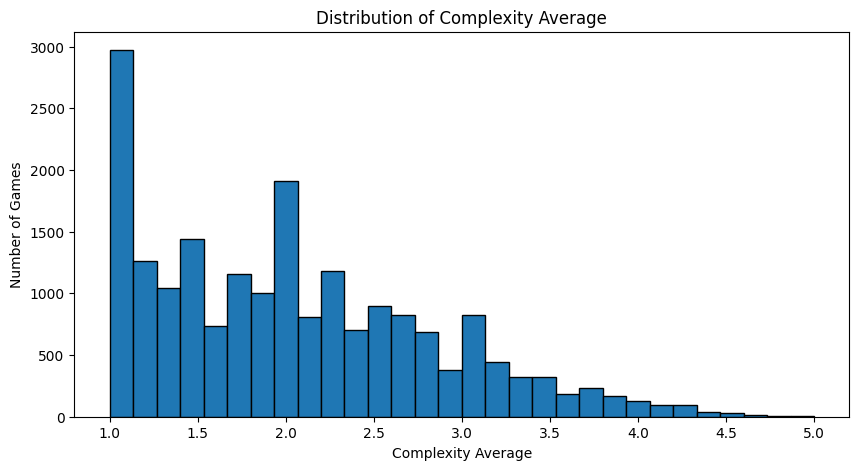

In [14]:
# Create histograms for every numerical candidate feature
for column in numeric_features:
    plt.figure(figsize=(10, 5))

    plt.hist(
        # Ignore missing values only for the chart
        # (because Matplotlib canot plot missing values directly
        df_eda[column].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Games")

    plt.show()

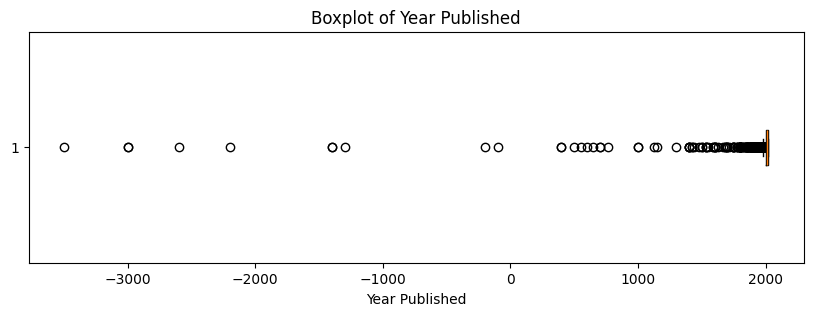

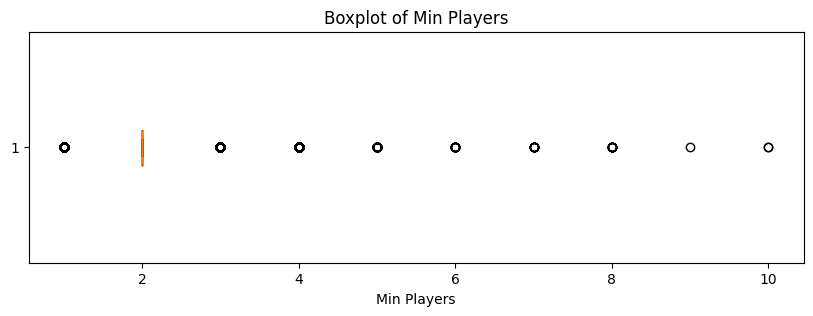

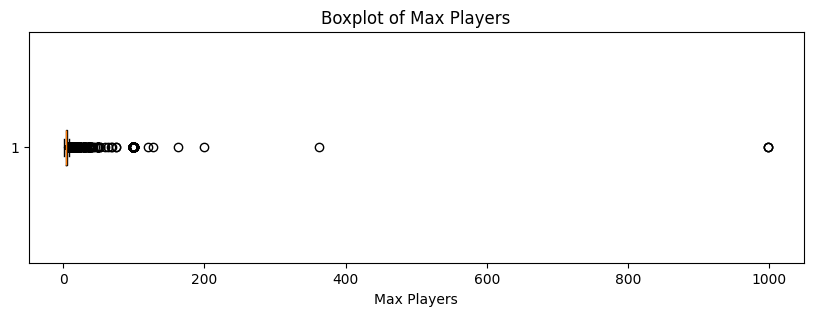

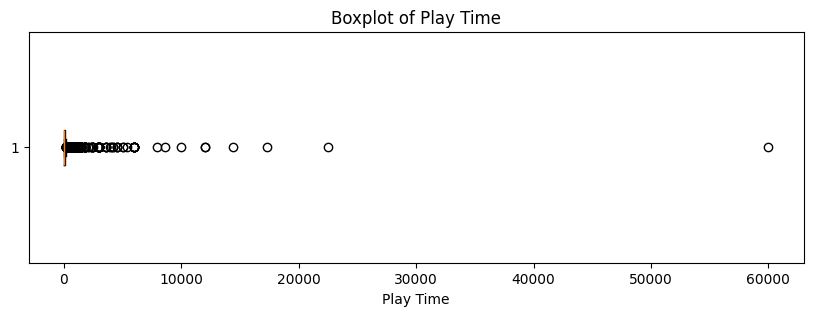

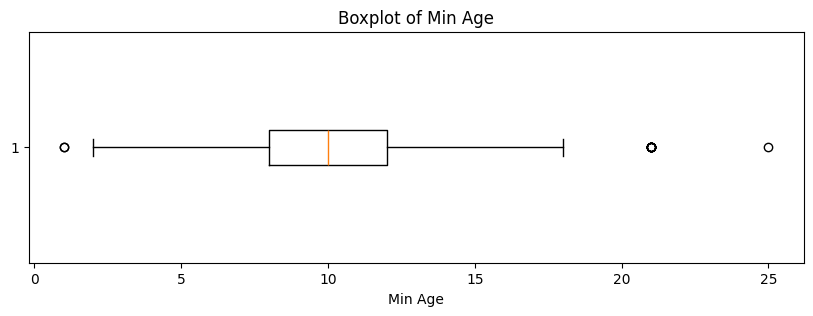

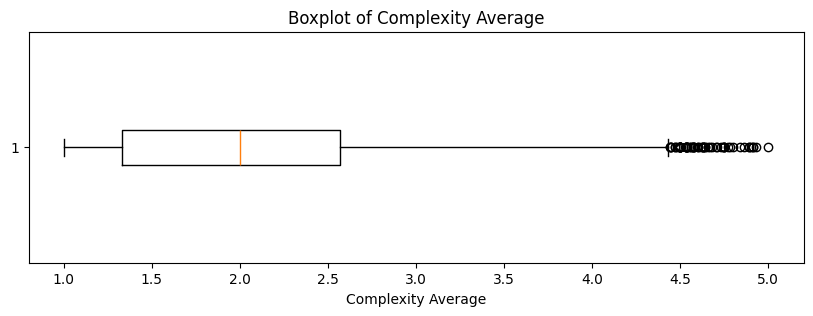

In [15]:
# Create boxplots for each numerical candidate feature
for column in numeric_features:
    plt.figure(figsize=(10, 3))

    plt.boxplot(
        df_eda[column].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

### Numerical Feature Distribution Result

The numerical candidate features sgow different distribution patterns.

`Year Published` is strongly concentrated around modern board games, especially games published from the 2000s onward. A small number of ancient games create extreme historical outliers, but these values are valid and were retained during data clening.

`Min Players` is highly concentrated around 2 players. This suggests that most games require at least two players, while games requiring larger minimum player counts are uncommon.

`Max Players` is right-skewed. Most games support a relatively small or moderate number of players, but a few games have very high maximum player counts.

`Play Time` is also strongly right-skewed. Most games have moderate play times, but a small number of campaign or large-scale games have exteremely long play times.

`Min Age` is mostly concentrated around comon recommended ages such as 8, 10, 12, and 14.

`Complexity Average` is mostly concentrated in the low-to-medium range, with few games reaching the highest complexity values.

The observed outliers appear meaningful for board game data and will not be removed during exploratory analysis. Potential transfromations for skewed features such as `Max Players` and `Play Time` may be considered later during feature engineering and model preparation.


## Analyse Numerical Feature Relationships with Rating Average

The numerical candudate features are compared with the prediction target, `Rating Average`.

This helps identify which features may contain usefil predictive information.

Correlation values are calculated to measzre simple linear relationships. Scatter plots are then used to visually inspect the relationship between each numerical feature and the target.

Correlation does not prove causation. It only shows whether two values tend to move together in the dataset.


In [16]:
# calculate correlations between numerical candidate
# feature and the prediction target
numeric_correlations = (
    df_eda[numeric_features + ["Rating Average"]]
    .corr(numeric_only=True)["Rating Average"]
    .drop("Rating Average")
    .sort_values(ascending=False)
    .to_frame(name="Correlation with Rating Average")
)

numeric_correlations
# Correlation values range from -1 to 1
# (-1=neg, +1=pos relation, 0=no linear relationshp)

,Correlation with Rating Average
Complexity Average,0.510871
Min Age,0.327548
Play Time,0.090287
Year Published,0.077419
Max Players,-0.040640
Min Players,-0.159966


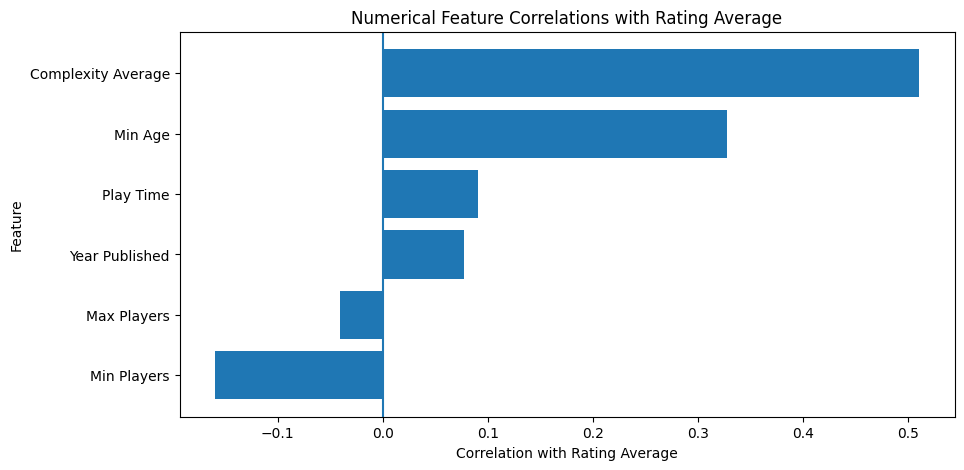

In [17]:
# Plot the feature correlations with Rating Average
plt.figure(figsize=(10, 5))

plt.barh(
    numeric_correlations.index,
    numeric_correlations["Correlation with Rating Average"]
)

plt.title("Numerical Feature Correlations with Rating Average")
plt.xlabel("Correlation with Rating Average")
plt.ylabel("Feature")

plt.axvline(0)

plt.gca().invert_yaxis()

plt.show()
# 0= in the middle, left is neg, right is pos

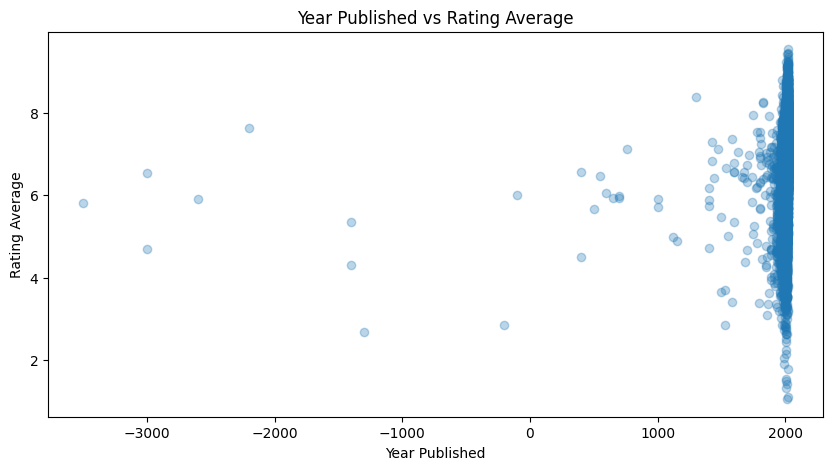

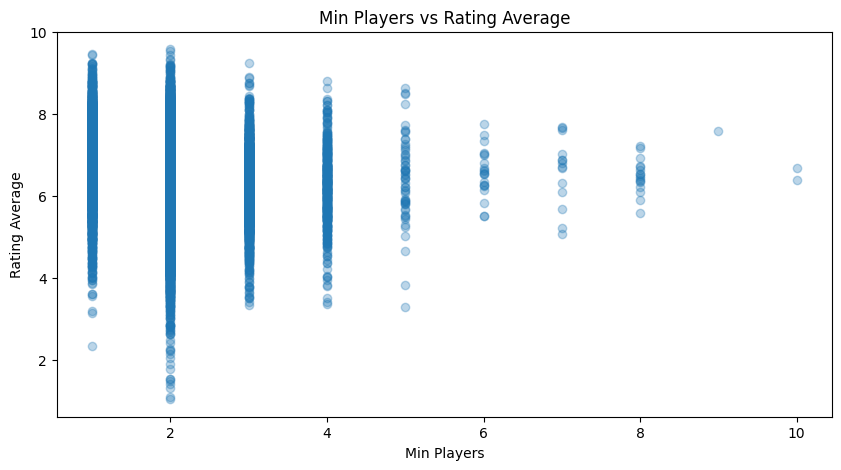

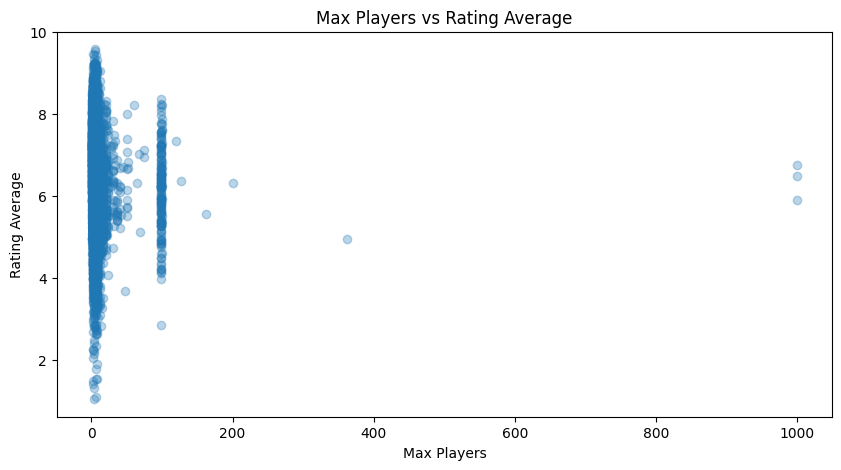

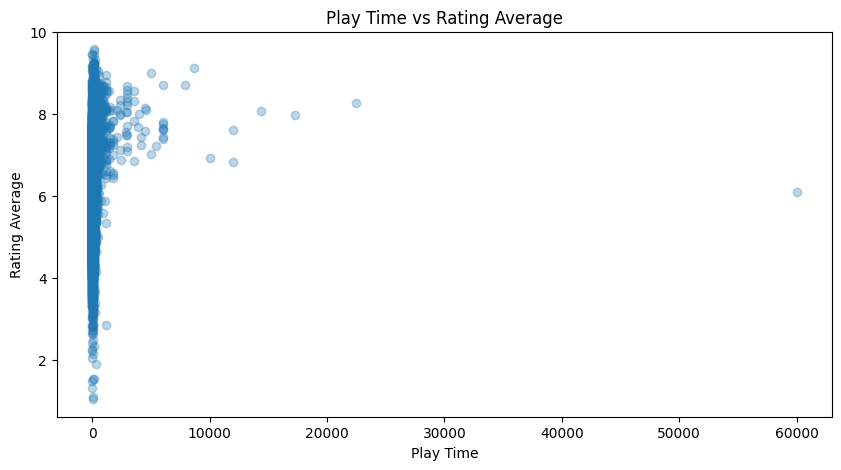

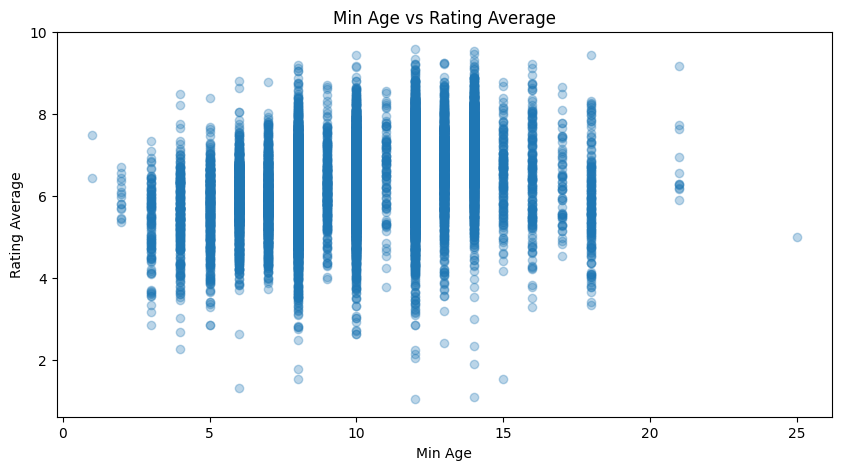

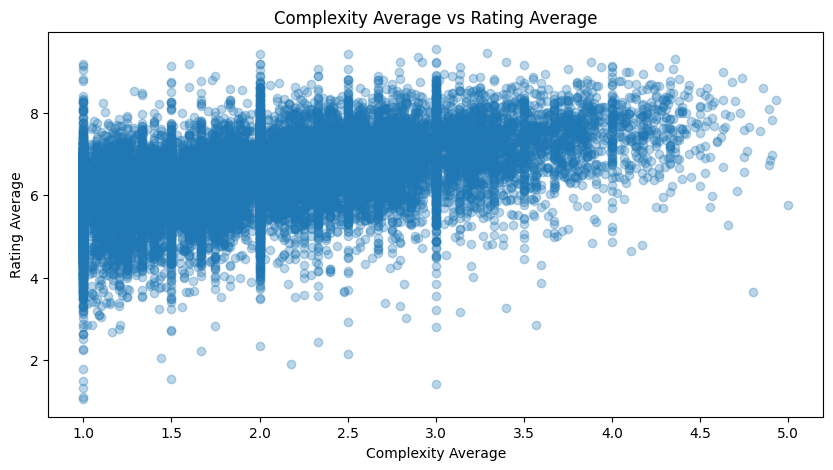

In [18]:
# Create scatter plots comparing each numerical feature
# with Rating Average
for column in numeric_features:
    plt.figure(figsize=(10, 5))

    plt.scatter(
        df_eda[column],
        df_eda["Rating Average"],
        alpha=0.3
    )

    plt.title(f"{column} vs Rating Average")
    plt.xlabel(column)
    plt.ylabel("Rating Average")

    plt.show()

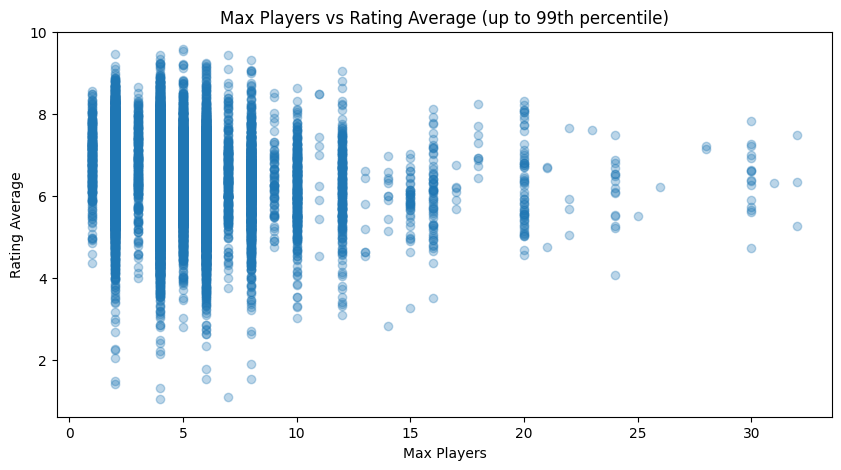

Max Players 99th percentile: 32.0


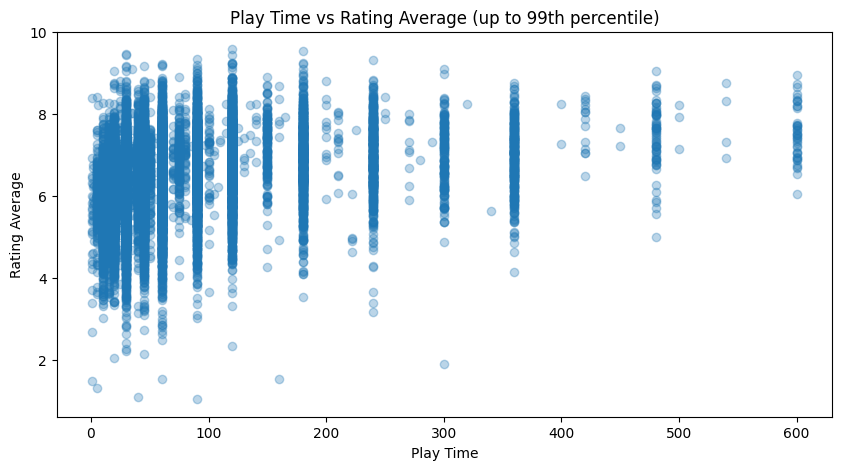

Play Time 99th percentile: 600.0


In [19]:
# Create focused scatter plots for heavily skewed features
# The 99th percentile is used only to make the chart easier to read
skewed_features = [
    "Max Players",
    "Play Time"
]

for column in skewed_features:
    upper_limit = df_eda[column].quantile(0.99)

    focused_data = df_eda[
        df_eda[column].notnull()
        & (df_eda[column] <= upper_limit)
    ]

    plt.figure(figsize=(10, 5))

    plt.scatter(
        focused_data[column],
        focused_data["Rating Average"],
        alpha=0.3
    )

    plt.title(
        f"{column} vs Rating Average "
        f"(up to 99th percentile)"
    )
    plt.xlabel(column)
    plt.ylabel("Rating Average")

    plt.show()

    print(f"{column} 99th percentile:", upper_limit)

### Numerical Feature Relationship Result

`Complexity Average` has the strogest numerical relationship with `Rating Average`, with a correlation of approximately 0.51. This suggests that more complex board games tens to receive higher average ratings in this dataset.

`Min Age` has a moderate positive correlation of approximately 0.33. This may indicate that games recommended for older players tend to receive higher ratings, possibly because these games are often more complex or strategic.

`Play Time` and `Year Published` have weak positive correlations with `Rating Average`. These features may contain some useful information, but they do not show a strong simpl elinear relationship with the target.

`Max Players` has a very weak negative correlation, close to zero. This suggests that maximum supported player count has litlte direct linear relationship with average rating.

`Min Players` has a weak negative correlation of approximately -0.16. This may suggest that games requiring more players to start are rated slightly lower on average, although the relationship is not really that strong.

The scatter plots support the correlation results. `Complexity Average` shows the clearest upward pattern with `Rating Average`, while most other numerical features slow weaker or less visible relationships.

The focused scatter plots for `Max Players` and `Play Time` used the 99th percenteg only for easier visual inspection. This did not remove data form dataset.


## Explore Mechanics and Domains

The `Mechanics` and `Domains` columns contain text-baesed information about each board game.

`Mechanics` describes gameplay systems such as drck building, worker placement, dice rolling, or hand management.

`Domains` describes broader game categories such as strategy games, family games, temathic games, or war games.

These columns may become useful features later, but they need special hadling because many games contain multiple mechanics or domains in the same cell.


In [20]:
# Preview the Mechanics and Domains columns
# to see how text values are stoired
df_eda[
    [
        "Name",
        "Mechanics",
        "Domains",
        "Rating Average"
    ]
].head(10)

,Name,Mechanics,Domains,Rating Average
0,Gloomhaven,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games",8.79
1,Pandemic Legacy: Season 1,"Action Points, Cooperative Game, Hand Manageme...","Strategy Games, Thematic Games",8.61
2,Brass: Birmingham,"Hand Management, Income, Loans, Market, Networ...",Strategy Games,8.66
3,Terraforming Mars,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games,8.43
4,Twilight Imperium: Fourth Edition,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games",8.70
5,Gloomhaven: Jaws of the Lion,"Action Queue, Campaign / Battle Card Driven, C...","Strategy Games, Thematic Games",8.87
6,Through the Ages: A New Story of Civilization,"Action Points, Auction/Bidding, Auction: Dutch...",Strategy Games,8.43
7,Gaia Project,"End Game Bonuses, Hexagon Grid, Income, Modula...",Strategy Games,8.49
8,Star Wars: Rebellion,"Area Majority / Influence, Area Movement, Area...",Thematic Games,8.42
9,Twilight Struggle,"Action/Event, Advantage Token, Area Majority /...","Strategy Games, Wargames",8.29


In [21]:
# Count how many rows contain Unkown values in Mechanics 
# and Domains to cofirm how much missing text info is
# replaced with "unknown" durinf data cleansing 
unknown_text_summary = pd.Series({
    "Mechanics Unknown Count": (df_eda["Mechanics"] == "Unknown").sum(),
    "Mechanics Unknown Percentage": (
        (df_eda["Mechanics"] == "Unknown").sum()
        / len(df_eda)
        * 100
    ).round(2),
    "Domains Unknown Count": (df_eda["Domains"] == "Unknown").sum(),
    "Domains Unknown Percentage": (
        (df_eda["Domains"] == "Unknown").sum()
        / len(df_eda)
        * 100
    ).round(2)
})

unknown_text_summary

Mechanics Unknown Count          1597.00
Mechanics Unknown Percentage        7.85
Domains Unknown Count           10158.00
Domains Unknown Percentage         49.94
dtype: float64

In [ ]:
# Create a helper function to split comma-separated text values
# this is for games with several mechanics


def split_text_column(dataframe, column_name):
    """
    Split a text column where each row may contain multiple 
    comma-separated values.

    Example:
    'Dice Rolling, Hand Management'

    becomes two separate values:
    'Dice Rolling'
    'Hand Management'
    """

    return (
        dataframe[column_name]
        .dropna()
        .str.split(",")
        .explode()
        .str.strip()
    )

In [ ]:
# Split the Mechanics column into individual mechanics


mechanics_split = split_text_column(df_eda, "Mechanics")

# Count most common mechanics, but no Unknown
top_mechanics = (
    mechanics_split[mechanics_split != "Unknown"]
    .value_counts()
    .head(15)
)

top_mechanics

Mechanics
Dice Rolling                     5672
Hand Management                  4152
Set Collection                   2733
Variable Player Powers           2534
Hexagon Grid                     2253
Simulation                       1944
Card Drafting                    1730
Tile Placement                   1692
Modular Board                    1623
Area Majority / Influence        1502
Grid Movement                    1478
Cooperative Game                 1402
Roll / Spin and Move             1303
Area Movement                    1122
Simultaneous Action Selection    1100
Name: count, dtype: int64

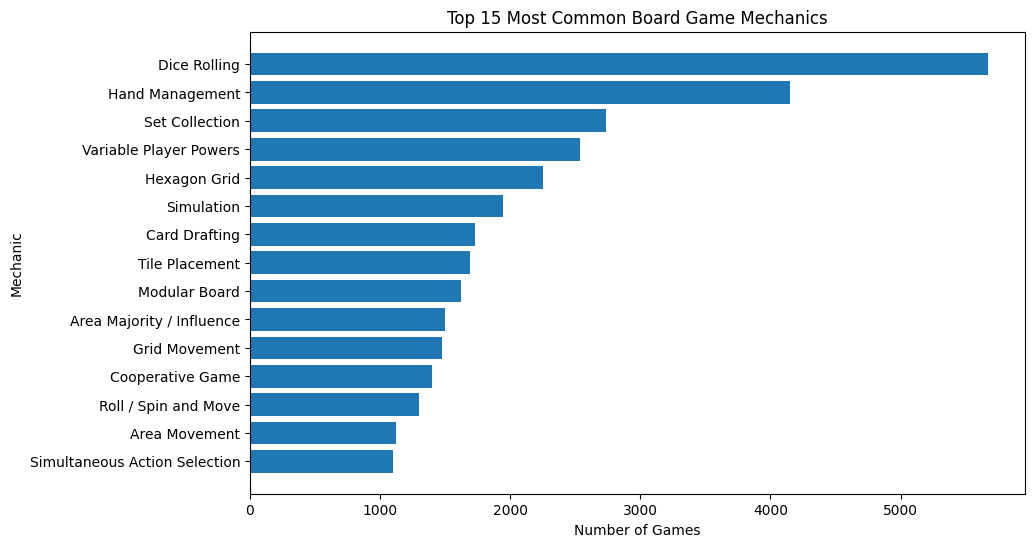

In [24]:
# Plot most common board game mechancis
plt.figure(figsize=(10, 6))

plt.barh(
    top_mechanics.index,
    top_mechanics.values
)

plt.title("Top 15 Most Common Board Game Mechanics")
plt.xlabel("Number of Games")
plt.ylabel("Mechanic")

plt.gca().invert_yaxis()

plt.show()

In [25]:
# Split the Domains column into individual domains
domains_split = split_text_column(df_eda, "Domains")

# Count most common domains but not Unknown
top_domains = (
    domains_split[domains_split != "Unknown"]
    .value_counts()
)

top_domains

Domains
Wargames              3316
Strategy Games        2205
Family Games          2173
Thematic Games        1174
Abstract Games        1070
Children's Games       849
Party Games            605
Customizable Games     297
Name: count, dtype: int64

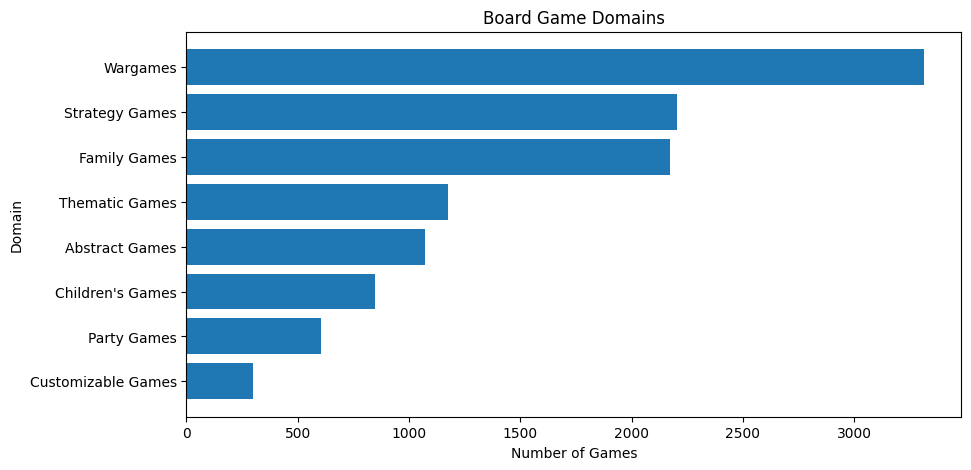

In [26]:
# Plot the board game domains
plt.figure(figsize=(10, 5))

plt.barh(
    top_domains.index,
    top_domains.values
)

plt.title("Board Game Domains")
plt.xlabel("Number of Games")
plt.ylabel("Domain")

plt.gca().invert_yaxis()

plt.show()

In [27]:
# Create a temporary table where every game can appear once per domain
domain_rating_data = (
    df_eda[
        [
            "Name",
            "Rating Average",
            "Domains"
        ]
    ]
    .assign(Domain=df_eda["Domains"].str.split(","))
    .explode("Domain")
)

# Clear spaces around domain names
domain_rating_data["Domain"] = domain_rating_data["Domain"].str.strip()

# Exclude Unknown domains
domain_rating_data = domain_rating_data[
    domain_rating_data["Domain"] != "Unknown"
]

# Calculate average rating and game count for aech domain
domain_rating_summary = (
    domain_rating_data
    .groupby("Domain")
    .agg(
        Average_Rating=("Rating Average", "mean"),
        Game_Count=("Name", "count")
    )
    .sort_values(
        by="Average_Rating",
        ascending=False
    )
)

domain_rating_summary

,Average_Rating,Game_Count
Domain,,
Strategy Games,6.957982,2205
Wargames,6.847437,3316
Thematic Games,6.789233,1174
Family Games,6.405568,2173
Customizable Games,6.364646,297
Party Games,6.285752,605
Abstract Games,6.230140,1070
Children's Games,5.511272,849


### Mechanics and Domains Result

The `Mechanics` and `Domains` columns contains multi-value text infroamtion, where one gave may belong to several mechanics or domains.

`Mechanics` contains 1,597 `Unknown` vleues, reperesenting 7.85% of the dataset. `Domains` contains 10,158 `Unknown` values, rerpesenting 49.94% of the dataset. This means that domain information is missing for alost half of the games, so it should be used carefully in future modleling.

The most common mechanics include `Dice Roling`, `Hand Management`, `Set Collection`, `Variable Player Poerws`, and `Hexagon Grid`.

The most common domains include `Wargames`, `Strategy Games`, `Family Games`, `Temathic Games`, and `Abstract Gamed`.

Average ratings vary by domain. `Strategy Games`, `Wargames`, and `Temathic Games` have the higehest average ratings among the listed domains, while `Children's Games` has the lowest average rating.

These text-based columns may be useeful for future feature engineering, but they will require trasnformation begore they can ve sued in a machine-learning model.


## Exploratory Data Analysis Summary

This notbook explored the cleaned BoardGameGeek dateset after the data cleaning phase.

The cleanead dataset contaiens 20,342 tows and 14 columns. The processed file was loaded successfully from `data/processed/bgg_cleaned.csv`, and the exepcted structure was confrmed.

### Remaining missing values

Some missing values remaim in the cleaned dataset.

The largest amount of missing numerical information is in `Min Age`, with 1,250 missing values, reperesenting 6.14% of the dataset. Other numerical columns have smaller missing percentages.

The prediction target, `Rating Average`, contains no missing valus.

No additional values were filled or removed during exploratory data analysis. These missing values will be handled after later during feature engineering and model preprocessing.

### Rating Average target

`Rating Average` is prediction target for this project.

The average rating is approxamately 6.40, and the median rating is approxamately 6.43. These values are verx close, which suggests that the target distribution is reasonably centrad around the middle rating range.

Most games are eated between 5 and 8. The largest rating band is 6-7, which contains 42.30% of the dataset.

Very low ratings bellow 4 and very high ratings above 9 are rare.

This means the future machine-learning model will mostly need to learn diffreences between games in the middle rating range rather than across the full 1-10 scale equally.

### Numerical features

The numerical candidate features explored were_

* `Year Published`
* `Min Players `
* `Max Players`
* `Play Time`
* `Mib Age`
* `Complexity Average`

`Complexity Average` has the strongest numerical relationship with `Rating Average`, with a correlation of approximately 0.51. This suggsts that more complex fames tend to receive higher average ratings in this dataset.

`Min Age` has a moderate positive correlation of approximately 0.33. This may indicate that games recommended for older players tend to receive higher ratings, maybe because they are often more complex or strategic.

`Play Time` and `Year Published` have weak positive relationships with the target.

`Max Players` have very little direct linear relationship with average rating.

`Min Players` have a weak negative relationship with averahe rating.

Several numerical features are skewed. Specifically, `Max Players` and `Play Time` contain very extremely high values. These values are not removed during EDA because they may represent valid board game records. Later feature engineering may consider transformations or caps for these skewed features.

### Mechanics and Domains

The `Mechanics` and `Domains` columns contain text-based, multi-value information.

`Mechanics` contains 1,597 `Unknown` values, and that us 7.85% of the dataset.

`Domains` has 10,158 `Unknown` values, which  is 49.94% of the dataset. This means domain information is missing for almost half of the games and should be used carefully in future modelling.

The most common mechanics include:

* `Dice Rolling`
* `Hand Management`
* `Set Collection`
* `Variable Player Powers`
* `Hexagon Grid`

The most common domains include:

* `Wargames`
* `Strategy Games`
* `Family Games`
* `Thematic Games`
* `Abstract Games`

Average ratings vary from domain to domain. `Strategy Games`, `Wargames`, and `Thematic Games` have relatively high average ratings, while `Children's Games` has the lowest average rating among the listed domains.

These text-based columns coukd be useful for future feature engineering, but they have to be transformed before they can be used in a machine-learning model.

### Key findings for future modelling

The best initial numerical feature appears to be `Complexity Average`.

`Min Age` looks promising and holds useful predictive information.

`Max Players` and `Play Time` are skewed and may need transformation during feature engineering.

`Mechanics` and `Domains` looks like holdning useful categorical information, but they require special handling because they have several values in single cell.

`BGG Rank`, `Users Rated`, and `Owned Users` were not treated as initial model features because they describe ranking or popularity after release and may introduce data leakage

The next project phase focuses on feature engineering and model preparation.
